In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
import lime
import lime.lime_tabular

import xgboost as xgb
import pickle

c:\Users\Swanandi\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
xgb_model = xgb.Booster()
xgb_model.load_model("../models/xgboost/xgb_fold_0.json")

In [3]:
df = pd.read_csv("../data/splits/val_fold_0.csv")

In [4]:
print(df.columns.tolist())

['hour_from_admission', 'heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c', 'systolic_bp', 'diastolic_bp', 'oxygen_device', 'oxygen_flow', 'mobility_score', 'nurse_alert', 'wbc_count', 'lactate', 'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score', 'age', 'gender', 'comorbidity_index', 'admission_type', 'deterioration_next_12h', 'patient_id', 'hr_std', 'NEWS2', 'MAP', 'pulse_pressure', 'spo2_fio2', 'heart_rate_roc', 'respiratory_rate_roc', 'spo2_pct_roc', 'temperature_c_roc', 'lactate_roc', 'heart_rate_acc', 'respiratory_rate_acc', 'spo2_pct_acc', 'temperature_c_acc', 'lactate_acc', 'heart_rate_roll_mean', 'heart_rate_roll_std', 'heart_rate_cv', 'respiratory_rate_roll_mean', 'respiratory_rate_roll_std', 'respiratory_rate_cv', 'spo2_pct_roll_mean', 'spo2_pct_roll_std', 'spo2_pct_cv', 'temperature_c_roll_mean', 'temperature_c_roll_std', 'temperature_c_cv', 'lactate_roll_mean', 'lactate_roll_std', 'lactate_cv', 'tachycardia_flag', 'temp_diff', 'fever_trend', 'hour_sin'

In [5]:
target_col = "deterioration_next_12h"

y_val = df[target_col]
X_val = df.drop(columns=[target_col])

In [6]:
if "patient_id" in X_val.columns:
    X_val = X_val.drop(columns=["patient_id"])

In [7]:
print(y_val.value_counts())

deterioration_next_12h
0    55475
1     3212
Name: count, dtype: int64


In [8]:
model_features = xgb_model.feature_names

X_val = X_val.reindex(columns=model_features)

X_val = X_val.fillna(0)
X_val = X_val.astype(np.float32)

In [9]:
dval = xgb.DMatrix(X_val)
probs = xgb_model.predict(dval)

In [10]:
# Balanced sampling
high_risk = X_val[y_val == 1].sample(300, random_state=42)
low_risk = X_val[y_val == 0].sample(300, random_state=42)

X_sample = pd.concat([high_risk, low_risk]).reset_index(drop=True)

In [11]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_sample)

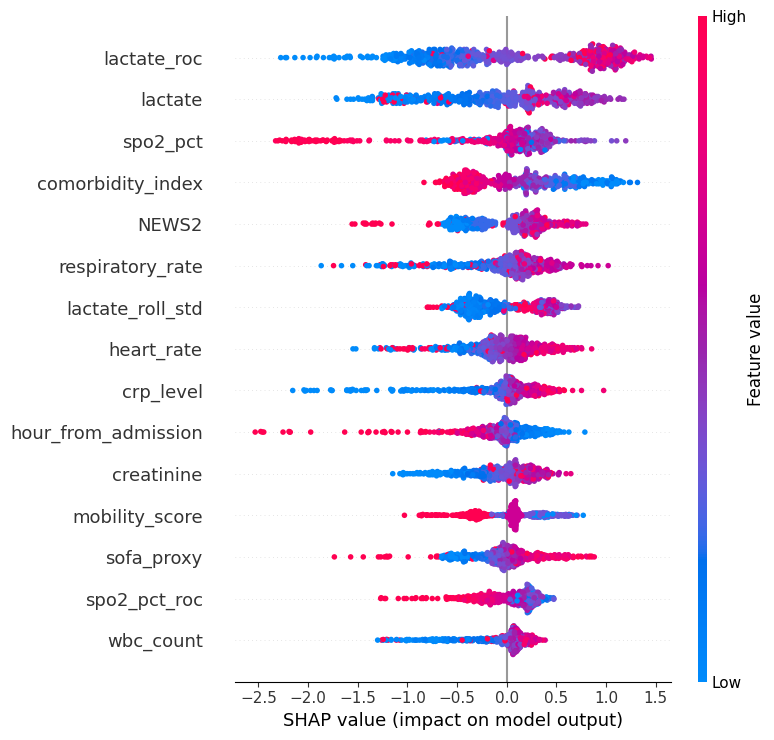

In [12]:
shap.summary_plot(shap_values, X_sample, max_display=15)

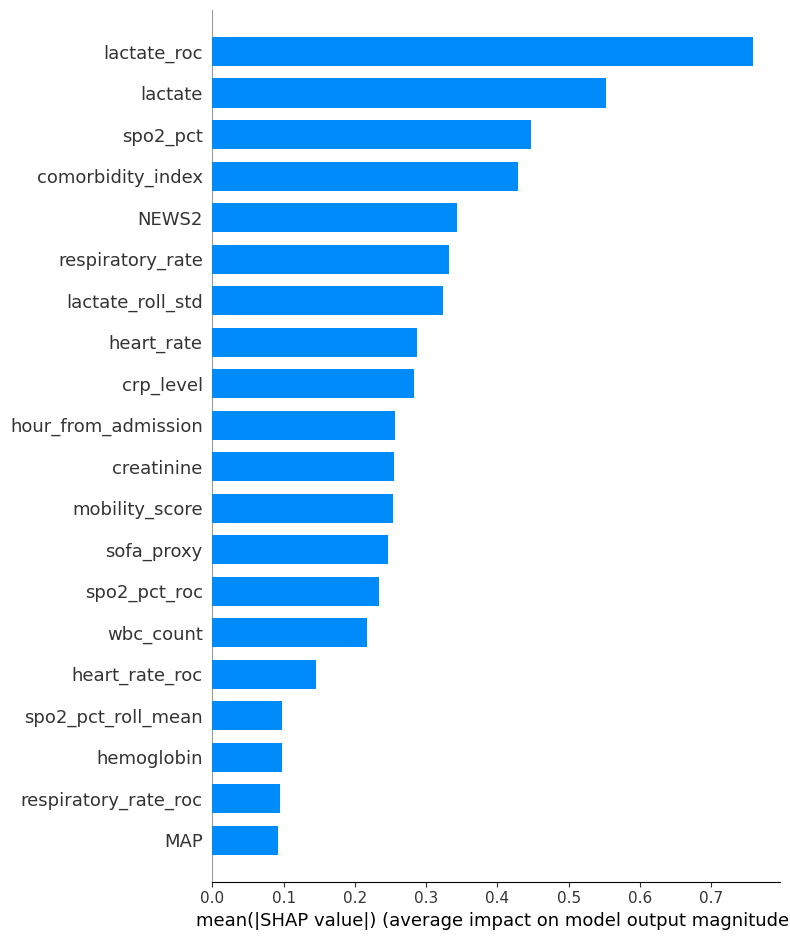

In [13]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

In [14]:
probs_sample = xgb_model.predict(xgb.DMatrix(X_sample))
idx = np.argmax(probs_sample)

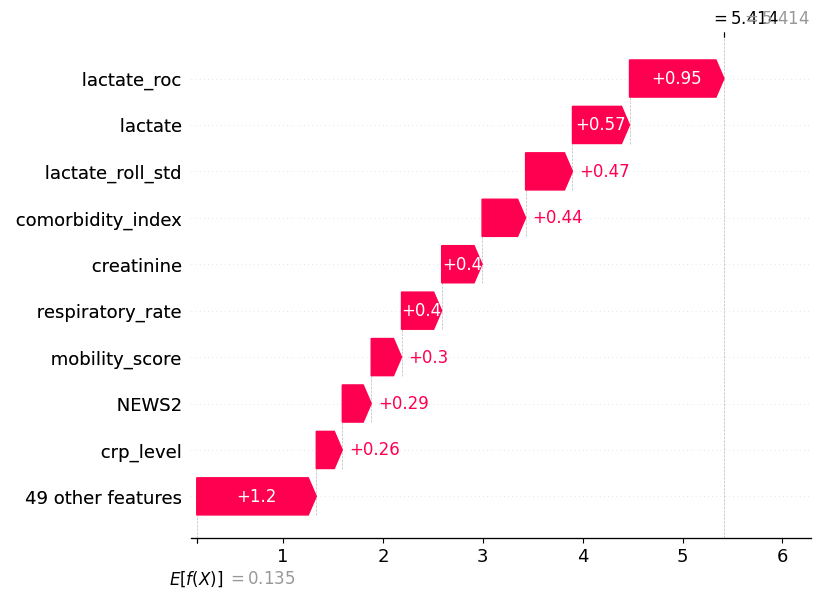

In [15]:
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[idx],
    X_sample.iloc[idx]
)

In [16]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_sample.iloc[idx]
)

In [17]:
def predict_fn(X):
    X_df = pd.DataFrame(X, columns=model_features)
    X_df = X_df.reindex(columns=model_features)
    X_df = X_df.fillna(0).astype(np.float32)

    d = xgb.DMatrix(X_df)
    probs = xgb_model.predict(d)

    return np.vstack([1 - probs, probs]).T

In [18]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_sample.values,
    feature_names=model_features,
    class_names=["Low Risk", "High Risk"],
    mode="classification"
)

In [19]:
exp = lime_explainer.explain_instance(
    X_sample.iloc[idx].values,
    predict_fn,
    num_features=10
)

[('lactate_roc > 0.16', 0.15080425512083592), ('90.71 < spo2_pct <= 93.26', 0.09358428684131515), ('crp_level > 45.34', 0.09211238479037441), ('comorbidity_index <= 2.00', 0.09124949935580437), ('mobility_score <= 1.00', 0.08762509416846201), ('creatinine > 1.57', 0.08533099489887191), ('1.93 < lactate <= 2.54', 0.08490406948109351), ('NEWS2 > 6.00', 0.05968715598156957), ('-0.61 < spo2_pct_roc <= -0.28', 0.05938171525159165), ('heart_rate > 100.42', 0.050680281647203736)]


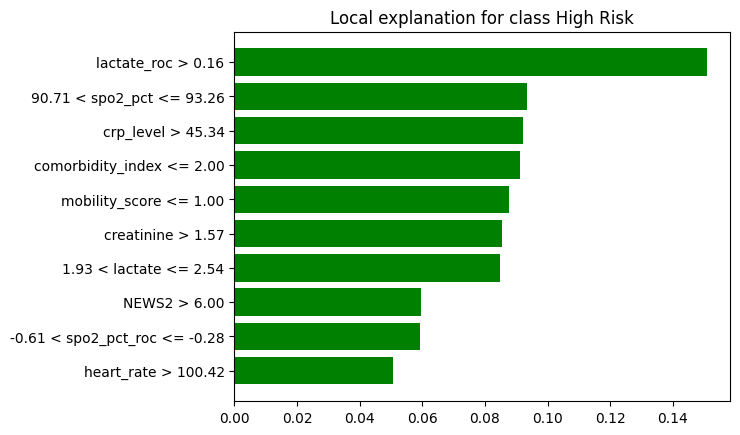

In [20]:
print(exp.as_list())

fig = exp.as_pyplot_figure()
plt.show()

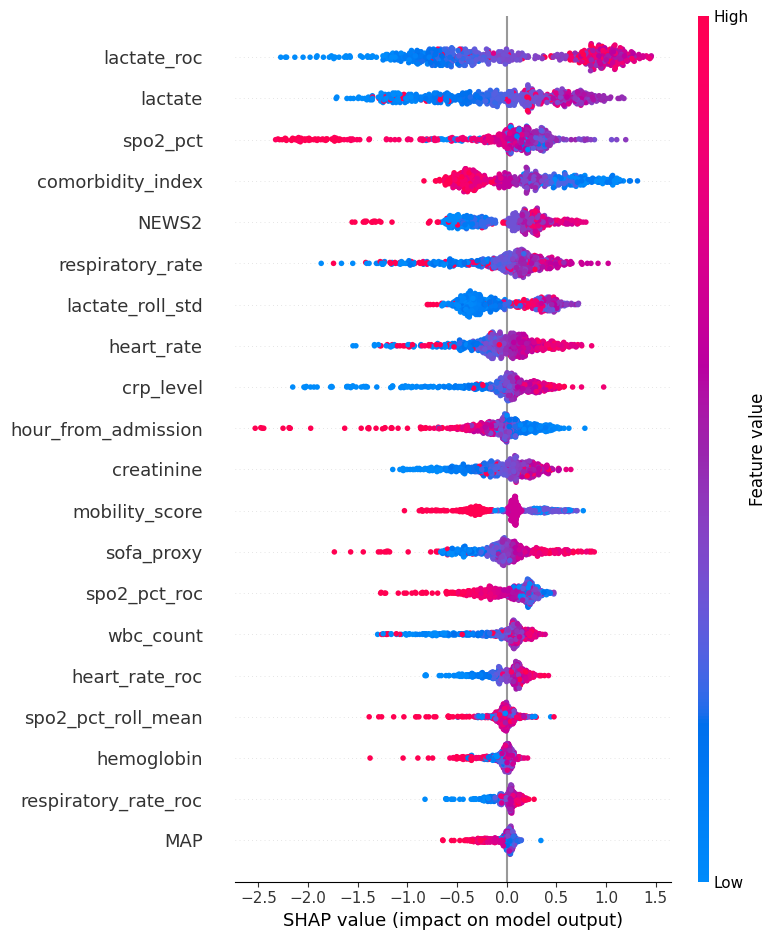

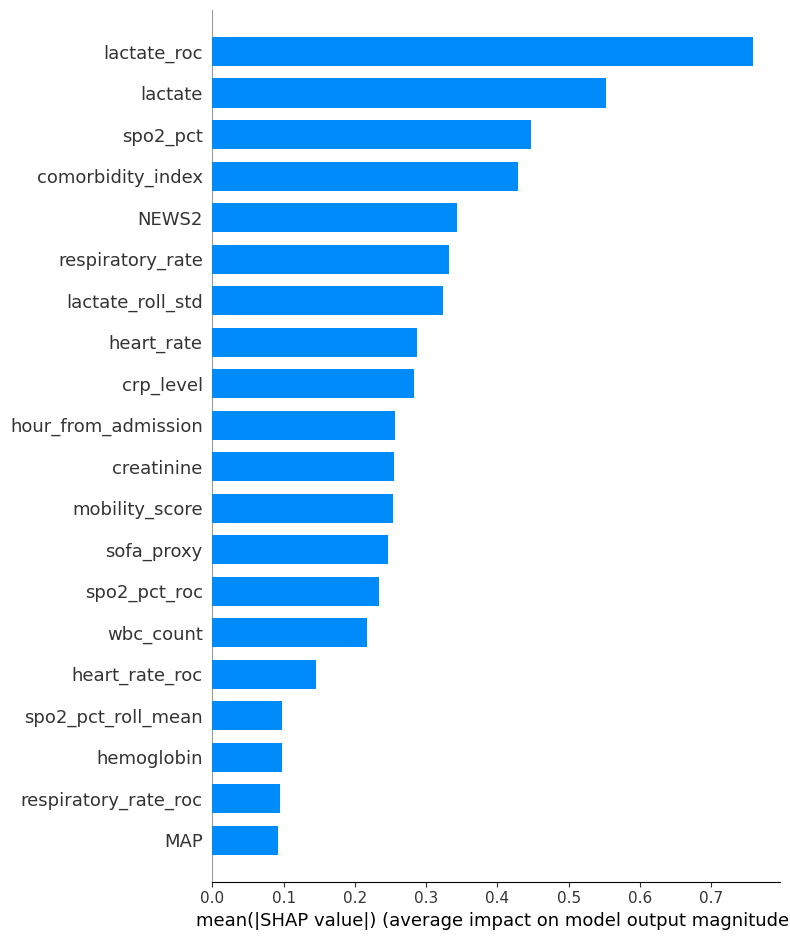

In [21]:
# SHAP beeswarm
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.savefig("../outputs/shap/shap_beeswarm.png", bbox_inches="tight")

# SHAP bar
plt.figure()
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.savefig("../outputs/shap/shap_bar.png", bbox_inches="tight")

In [22]:
high_idx = np.argmax(probs_sample)
low_idx = np.argmin(probs_sample)
mid_idx = np.argsort(probs_sample)[len(probs_sample)//2]

indices = [high_idx, mid_idx, low_idx]

for i in indices:
    print("\n==== Patient", i, "====")
    print("Risk:", probs_sample[i])

    exp = lime_explainer.explain_instance(
        X_sample.iloc[i].values,
        predict_fn,
        num_features=5
    )

    print(exp.as_list())


==== Patient 221 ====
Risk: 0.99556535
[('lactate_roc > 0.16', 0.13068820217500726), ('comorbidity_index <= 2.00', 0.1122668331212058), ('crp_level > 45.34', 0.08895396376020627), ('1.93 < lactate <= 2.54', 0.08358687339043766), ('mobility_score <= 1.00', 0.07930410736846834)]

==== Patient 350 ====
Risk: 0.18920521
[('lactate_roc <= -0.00', -0.20555571143405485), ('respiratory_rate <= 17.82', -0.0817383916422733), ('1.93 < lactate <= 2.54', 0.07067402507763657), ('lactate_roll_std <= 0.07', -0.0651935291369023), ('NEWS2 <= 2.00', -0.05938370481315827)]

==== Patient 427 ====
Risk: 3.0353633e-06
[('lactate_roc > 0.16', 0.12898826324447304), ('lactate > 2.54', 0.11236335466068587), ('mobility_score <= 1.00', 0.07449216120854531), ('crp_level > 45.34', 0.07403457457844365), ('creatinine > 1.57', 0.06937889563194327)]
